In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")

# Load source files from the project data folder
monthly = pd.read_csv("data/exhibit_6.csv")
daily = pd.read_csv("data/exhibit_7.csv")

# Standardize column names so both datasets use the same fuel labels
monthly = monthly.rename(columns={"Month": "Date"})
daily = daily.rename(columns={"Pet": "Petrol", "Dies": "Diesel"})

# Parse dates
monthly["Date"] = pd.to_datetime(monthly["Date"], format="%b-%y", errors="coerce")

# Daily file stores month-day only (e.g., 6-1). Use a reference year for plotting.
daily["Date"] = pd.to_datetime("2015-" + daily["Date"], format="%Y-%m-%d", errors="coerce")

# Keep and clean relevant columns
fuels = ["HSP", "Petrol", "Diesel"]

monthly = monthly[["Date", *fuels]].copy()
daily = daily[["Date", *fuels, "Day"]].copy()

for c in fuels:
    monthly[c] = pd.to_numeric(monthly[c], errors="coerce")
    daily[c] = pd.to_numeric(daily[c], errors="coerce")

monthly = monthly.dropna(subset=["Date", *fuels]).sort_values("Date")
daily = daily.dropna(subset=["Date", *fuels]).sort_values("Date")

print("Monthly rows:", len(monthly))
print("Daily rows:", len(daily))
monthly.head()

Monthly rows: 86
Daily rows: 393


,Date,HSP,Petrol,Diesel
0,2009-04-01,31616,31861,149389
1,2009-05-01,33098,33064,165037
2,2009-06-01,31780,33568,180344
3,2009-07-01,27186,28994,130538
4,2009-08-01,27286,29333,113378


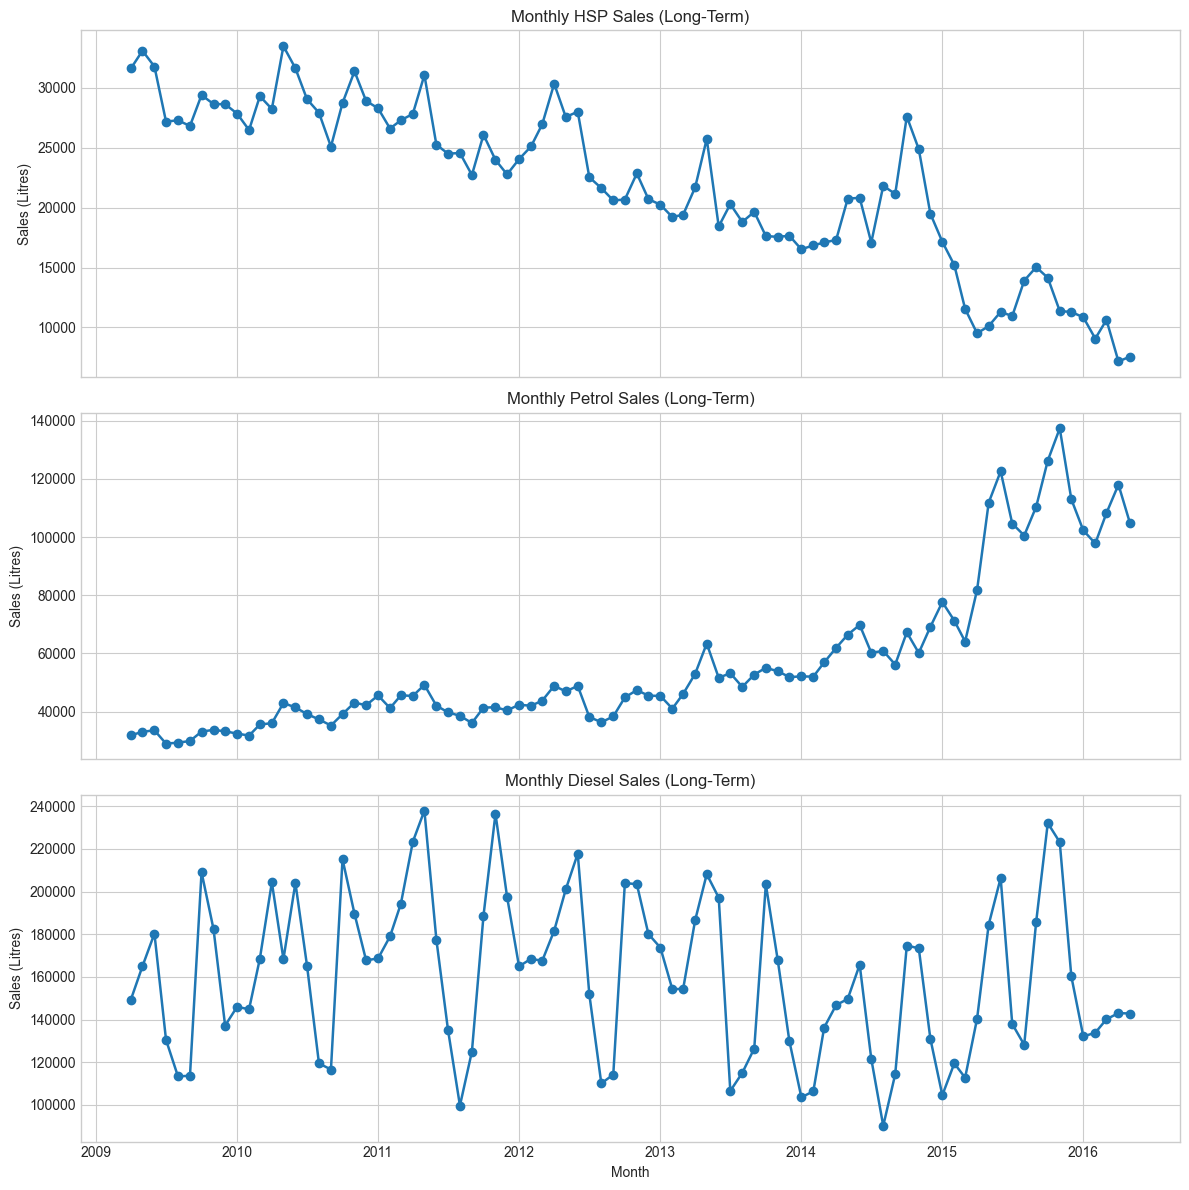

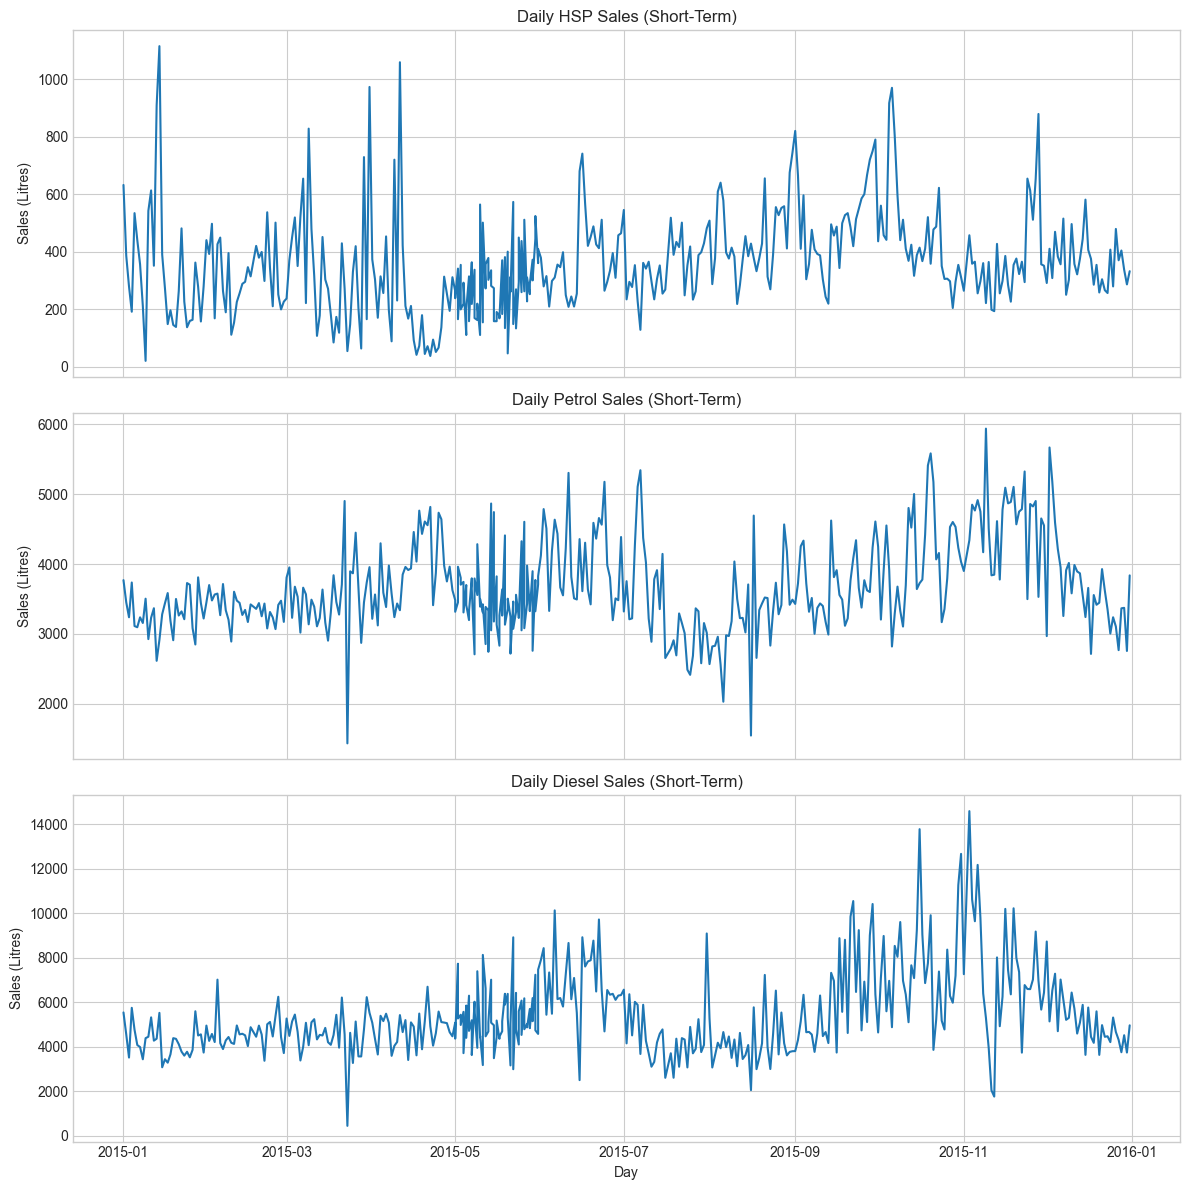

In [59]:
# Long-term view: monthly sales (Exhibit 6)
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
for ax, fuel in zip(axes, fuels):
    ax.plot(monthly["Date"], monthly[fuel], marker="o", linewidth=1.8)
    ax.set_title(f"Monthly {fuel} Sales (Long-Term)")
    ax.set_ylabel("Sales (Litres)")

axes[-1].set_xlabel("Month")
plt.tight_layout()
plt.show()

# Short-term view: daily sales (Exhibit 7)
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
for ax, fuel in zip(axes, fuels):
    ax.plot(daily["Date"], daily[fuel], linewidth=1.5)
    ax.set_title(f"Daily {fuel} Sales (Short-Term)")
    ax.set_ylabel("Sales (Litres)")

axes[-1].set_xlabel("Day")
plt.tight_layout()
plt.show()

## Moving Average

$$
N = \frac{2-\alpha}{\alpha}
$$

$$
F_t = \frac{1}{N}\sum_{i=1}^{N} D_{t-i}
$$

$$
e_t = F_t - D_t
$$

$$
\text{MAD} = \text{mean}(|e_t|), \quad \text{MAPE} = \text{mean}\left(\left|\frac{e_t}{D_t}\right|\right)\times100
$$

In [60]:
# Lecture parameter
alpha = 0.2
N_exact = (2 - alpha) / alpha
N = int(round(N_exact))

print(f"alpha = {alpha}")
print(f"Computed N = (2-alpha)/alpha = {N_exact}")
print(f"Using N = {N} periods")


def moving_average_metrics(df, fuels, dataset_name, n):
    results = []

    for fuel in fuels:
        tmp = df[["Date", fuel]].copy()

        # F_t = (1/N) * (D_{t-1} + ... + D_{t-N})
        tmp["Forecast"] = tmp[fuel].shift(1).rolling(window=n).mean()

        # e_t = F_t - D_t
        tmp["Error"] = tmp["Forecast"] - tmp[fuel]

        # Remove NaN rows caused by shift + rolling window
        eval_df = tmp.dropna(subset=["Forecast", "Error", fuel]).copy()

        # For MAPE, keep rows with non-zero demand to avoid division by zero
        eval_df_mape = eval_df[eval_df[fuel] != 0].copy()

        mad = eval_df["Error"].abs().mean()
        mape = (eval_df_mape["Error"].abs() / eval_df_mape[fuel].abs()).mean() * 100

        results.append({
            "Dataset": dataset_name,
            "Fuel": fuel,
            "Alpha": alpha,
            "N": n,
            "MAD": mad,
            "MAPE (%)": mape,
            "Evaluated Rows": len(eval_df),
        })

    return pd.DataFrame(results)


monthly_ma_results = moving_average_metrics(monthly, fuels, "Monthly", N)
daily_ma_results = moving_average_metrics(daily, fuels, "Daily", N)

ma_results = pd.concat([monthly_ma_results, daily_ma_results], ignore_index=True)
ma_results = ma_results[["Dataset", "Fuel", "Alpha", "N", "MAD", "MAPE (%)", "Evaluated Rows"]]
ma_results = ma_results.sort_values(["Dataset", "Fuel"]).reset_index(drop=True)

ma_results_display = ma_results.copy()
ma_results_display[["MAD", "MAPE (%)"]] = ma_results_display[["MAD", "MAPE (%)"]].round(3)

print("\nN-Period Moving Average Forecast Accuracy")
display(ma_results_display)

alpha = 0.2
Computed N = (2-alpha)/alpha = 9.0
Using N = 9 periods

N-Period Moving Average Forecast Accuracy


,Dataset,Fuel,Alpha,N,MAD,MAPE (%),Evaluated Rows
0,Daily,Diesel,0.2,9,1105.906,23.890,384
1,Daily,HSP,0.2,9,123.335,46.643,384
2,Daily,Petrol,0.2,9,414.882,11.678,384
3,Monthly,Diesel,0.2,9,32170.452,21.530,77
4,Monthly,HSP,0.2,9,2899.527,17.140,77
5,Monthly,Petrol,0.2,9,7506.905,10.781,77


## Exponential Smoothing

$$
F_t = \alpha D_{t-1} + (1-\alpha)F_{t-1}
$$

$$
e_t = F_t - D_t
$$

$$
\text{MAD} = \text{mean}(|e_t|), \quad \text{MAPE} = \text{mean}\left(\left|\frac{e_t}{D_t}\right|\right)\times100
$$

In [61]:
alpha_es = 0.2
N_es = int(round((2 - alpha_es) / alpha_es))


def exponential_smoothing_metrics(df, fuels, dataset_name, alpha, n):
    rows = []

    for fuel in fuels:
        y = df[fuel].to_numpy(dtype=float)
        m = len(y)

        # Moving-average forecasts for initialization: F_t = mean(D_{t-1}, ..., D_{t-N})
        ma_forecast = pd.Series(y).shift(1).rolling(window=n).mean().to_numpy()

        f = np.full(m, np.nan)

        # Initialize first exponential forecast with first available moving-average forecast
        first_idx = np.where(~np.isnan(ma_forecast))[0]
        if len(first_idx) == 0:
            continue
        start = int(first_idx[0])
        f[start] = ma_forecast[start]

        # Recursive formula: F_t = alpha*D_{t-1} + (1-alpha)*F_{t-1}
        for t in range(start + 1, m):
            f[t] = alpha * y[t - 1] + (1 - alpha) * f[t - 1]

        e = f - y  # e_t = F_t - D_t

        valid = ~np.isnan(f)
        non_zero = valid & (y != 0)

        mad = np.mean(np.abs(e[valid]))
        mape = np.mean(np.abs(e[non_zero] / y[non_zero])) * 100

        rows.append({
            "Dataset": dataset_name,
            "Fuel": fuel,
            "Alpha": alpha,
            "N_init": n,
            "MAD": mad,
            "MAPE (%)": mape,
            "Evaluated Rows": int(valid.sum()),
        })

    return pd.DataFrame(rows)


es_monthly = exponential_smoothing_metrics(monthly, fuels, "Monthly", alpha_es, N_es)
es_daily = exponential_smoothing_metrics(daily, fuels, "Daily", alpha_es, N_es)

es_results = pd.concat([es_monthly, es_daily], ignore_index=True)
es_results = es_results[["Dataset", "Fuel", "Alpha", "N_init", "MAD", "MAPE (%)", "Evaluated Rows"]]
es_results = es_results.sort_values(["Dataset", "Fuel"]).reset_index(drop=True)

es_results_display = es_results.copy()
es_results_display[["MAD", "MAPE (%)"]] = es_results_display[["MAD", "MAPE (%)"]].round(3)

print(f"alpha = {alpha_es}, N_init = {N_es}")
print("\nExponential Smoothing Accuracy")
display(es_results_display)

alpha = 0.2, N_init = 9

Exponential Smoothing Accuracy


,Dataset,Fuel,Alpha,N_init,MAD,MAPE (%),Evaluated Rows
0,Daily,Diesel,0.2,9,1080.633,23.364,384
1,Daily,HSP,0.2,9,116.709,43.928,384
2,Daily,Petrol,0.2,9,416.046,11.721,384
3,Monthly,Diesel,0.2,9,30855.144,20.579,77
4,Monthly,HSP,0.2,9,2619.381,15.415,77
5,Monthly,Petrol,0.2,9,6765.810,9.811,77


## Holt And Winters

$$
S_t = \alpha D_t + (1-\alpha)(S_{t-1}+G_{t-1})
$$

$$
G_t = \beta(S_t-S_{t-1}) + (1-\beta)G_{t-1}
$$

$$
F_{t+k} = S_t + kG_t
$$

$$
S_t = \alpha\left(\frac{D_t}{I_{t-L}}\right) + (1-\alpha)(S_{t-1}+G_{t-1})
$$

$$
G_t = \beta(S_t-S_{t-1}) + (1-\beta)G_{t-1}
$$

$$
I_t = \gamma\left(\frac{D_t}{S_t}\right) + (1-\gamma)I_{t-L}
$$

In [67]:
alpha_h = 0.2
beta_h = 0.15
gamma_w = 0.1
L_monthly = 12
L_daily = 7


def regression_init(y, init_len):
    x = np.arange(1, init_len + 1, dtype=float)
    slope, intercept = np.polyfit(x, y[:init_len], 1)
    return intercept, slope


def regression_metrics(df, fuels, dataset_name):
    rows = []

    for fuel in fuels:
        y = df[fuel].to_numpy(dtype=float)
        t = np.arange(1, len(y) + 1, dtype=float)

        slope, intercept = np.polyfit(t, y, 1)
        y_hat = intercept + slope * t

        e = y_hat - y
        valid = ~np.isnan(y_hat)
        non_zero = valid & (y != 0)

        mad = np.mean(np.abs(e[valid]))
        mape = np.mean(np.abs(e[non_zero] / y[non_zero])) * 100

        rows.append({
            "Dataset": dataset_name,
            "Fuel": fuel,
            "Intercept": intercept,
            "Slope": slope,
            "MAD": mad,
            "MAPE (%)": mape,
            "Evaluated Rows": int(valid.sum()),
        })

    return pd.DataFrame(rows)


def seasonal_indices_from_full_dataset(y, season_pos, season_len):
    t = np.arange(1, len(y) + 1, dtype=float)
    slope, intercept = np.polyfit(t, y, 1)
    trend = intercept + slope * t
    trend = np.where(np.abs(trend) < 1e-8, 1e-8, trend)

    ratios = y / trend
    ratio_by_season = pd.DataFrame({"Season": season_pos, "Ratio": ratios}).groupby("Season")["Ratio"].mean()

    season_base = np.ones(season_len, dtype=float)
    default_ratio = np.mean(ratios[np.isfinite(ratios)]) if np.isfinite(ratios).any() else 1.0
    for s in range(season_len):
        season_base[s] = ratio_by_season.get(s, default_ratio)

    season_base = season_base * (season_len / np.sum(season_base))
    return season_base


def additive_seasonal_init(y, season_pos, season_len):
    overall = np.mean(y)
    season_means = pd.DataFrame({"Season": season_pos, "y": y}).groupby("Season")["y"].mean()

    s0 = np.zeros(season_len, dtype=float)
    for i in range(season_len):
        s0[i] = season_means.get(i, overall) - overall

    s0 = s0 - np.mean(s0)
    return s0


def holt_metrics(df, fuels, dataset_name, alpha, beta, init_len):
    rows = []

    for fuel in fuels:
        y = df[fuel].to_numpy(dtype=float)
        m = len(y)
        k = min(init_len, m)

        S_prev, G_prev = regression_init(y, k)
        f = np.full(m, np.nan)

        for t in range(m):
            f[t] = S_prev + G_prev
            S_t = alpha * y[t] + (1 - alpha) * (S_prev + G_prev)
            G_t = beta * (S_t - S_prev) + (1 - beta) * G_prev
            S_prev, G_prev = S_t, G_t

        e = f - y
        idx = np.arange(m)
        valid = (~np.isnan(f)) & (idx >= k)
        non_zero = valid & (y != 0)

        mad = np.mean(np.abs(e[valid]))
        mape = np.mean(np.abs(e[non_zero] / y[non_zero])) * 100

        rows.append({
            "Dataset": dataset_name,
            "Fuel": fuel,
            "Alpha": alpha,
            "Beta": beta,
            "MAD": mad,
            "MAPE (%)": mape,
            "Evaluated Rows": int(valid.sum()),
        })

    return pd.DataFrame(rows)


def winter_multiplicative_metrics(df, fuels, dataset_name, alpha, beta, gamma, season_len, init_len, season_pos):
    rows = []

    for fuel in fuels:
        y = df[fuel].to_numpy(dtype=float)
        m = len(y)
        if m <= season_len:
            continue

        k = min(init_len, m)
        S_prev, G_prev = regression_init(y, k)

        season_base = seasonal_indices_from_full_dataset(y, season_pos, season_len)
        c = np.array([season_base[p] for p in season_pos], dtype=float)

        f = np.full(m, np.nan)
        eps = 1e-8

        for t in range(season_len, m):
            f[t] = (S_prev + G_prev) * c[t - season_len]

            c_lag = c[t - season_len] if abs(c[t - season_len]) > eps else eps
            S_t = alpha * (y[t] / c_lag) + (1 - alpha) * (S_prev + G_prev)
            G_t = beta * (S_t - S_prev) + (1 - beta) * G_prev
            S_safe = S_t if abs(S_t) > eps else eps
            c[t] = gamma * (y[t] / S_safe) + (1 - gamma) * c[t - season_len]

            S_prev, G_prev = S_t, G_t

        e = f - y
        idx = np.arange(m)
        valid = (~np.isnan(f)) & (idx >= max(season_len, k))
        non_zero = valid & (y != 0)

        mad = np.mean(np.abs(e[valid]))
        mape = np.mean(np.abs(e[non_zero] / y[non_zero])) * 100

        rows.append({
            "Dataset": dataset_name,
            "Fuel": fuel,
            "Alpha": alpha,
            "Beta": beta,
            "Gamma": gamma,
            "L": season_len,
            "MAD": mad,
            "MAPE (%)": mape,
            "Evaluated Rows": int(valid.sum()),
        })

    return pd.DataFrame(rows)


def holt_daily_metrics_strict(df, fuels, alpha, beta, init_len=365):
    rows = []

    for fuel in fuels:
        y = df[fuel].to_numpy(dtype=float)
        m = len(y)
        k = min(init_len, m)
        S_prev, G_prev = regression_init(y, k)

        f = np.full(m, np.nan)
        for t in range(m):
            f[t] = S_prev + G_prev
            S_t = alpha * y[t] + (1 - alpha) * (S_prev + G_prev)
            G_t = beta * (S_t - S_prev) + (1 - beta) * G_prev
            S_prev, G_prev = S_t, G_t

        e = f - y
        idx = np.arange(m)
        valid = (~np.isnan(f)) & (idx >= k)
        non_zero = valid & (y != 0)

        rows.append({
            "Dataset": "Daily",
            "Fuel": fuel,
            "Alpha": alpha,
            "Beta": beta,
            "MAD": np.mean(np.abs(e[valid])),
            "MAPE (%)": np.mean(np.abs(e[non_zero] / y[non_zero])) * 100,
            "Evaluated Rows": int(valid.sum()),
        })

    return pd.DataFrame(rows)


def winter_daily_additive_metrics_strict(df, fuels, alpha, beta, gamma, season_len=7, init_len=365):
    rows = []
    season_pos = df["Date"].dt.dayofweek.to_numpy(dtype=int)

    for fuel in fuels:
        y = df[fuel].to_numpy(dtype=float)
        m = len(y)
        if m <= season_len:
            continue

        k = min(init_len, m)
        l_prev, b_prev = regression_init(y, k)
        s0 = additive_seasonal_init(y, season_pos, season_len)

        season = np.array([s0[p] for p in season_pos], dtype=float)
        f = np.full(m, np.nan)

        for t in range(season_len, m):
            f[t] = l_prev + b_prev + season[t - season_len]

            l_t = alpha * (y[t] - season[t - season_len]) + (1 - alpha) * (l_prev + b_prev)
            b_t = beta * (l_t - l_prev) + (1 - beta) * b_prev
            s_t = gamma * (y[t] - l_t) + (1 - gamma) * season[t - season_len]

            season[t] = s_t
            l_prev, b_prev = l_t, b_t

        e = f - y
        idx = np.arange(m)
        valid = (~np.isnan(f)) & (idx >= max(k, season_len))
        non_zero = valid & (y != 0)

        rows.append({
            "Dataset": "Daily",
            "Fuel": fuel,
            "Alpha": alpha,
            "Beta": beta,
            "Gamma": gamma,
            "L": season_len,
            "MAD": np.mean(np.abs(e[valid])),
            "MAPE (%)": np.mean(np.abs(e[non_zero] / y[non_zero])) * 100,
            "Evaluated Rows": int(valid.sum()),
        })

    return pd.DataFrame(rows)


reg_monthly = regression_metrics(monthly, fuels, "Monthly")
reg_daily = regression_metrics(daily, fuels, "Daily")
regression_results = pd.concat([reg_monthly, reg_daily], ignore_index=True)
regression_results = regression_results[["Dataset", "Fuel", "Intercept", "Slope", "MAD", "MAPE (%)", "Evaluated Rows"]]
regression_results = regression_results.sort_values(["Dataset", "Fuel"]).reset_index(drop=True)

holt_monthly = holt_metrics(monthly, fuels, "Monthly", alpha_h, beta_h, init_len=12)
holt_daily = holt_daily_metrics_strict(daily, fuels, alpha_h, beta_h, init_len=365)
holt_results = pd.concat([holt_monthly, holt_daily], ignore_index=True)
holt_results = holt_results[["Dataset", "Fuel", "Alpha", "Beta", "MAD", "MAPE (%)", "Evaluated Rows"]]
holt_results = holt_results.sort_values(["Dataset", "Fuel"]).reset_index(drop=True)

month_pos = (monthly["Date"].dt.month - 1).to_numpy(dtype=int)
winter_monthly = winter_multiplicative_metrics(
    monthly, fuels, "Monthly", alpha_h, beta_h, gamma_w, season_len=L_monthly, init_len=12, season_pos=month_pos
)
winter_daily = winter_daily_additive_metrics_strict(daily, fuels, alpha_h, beta_h, gamma_w, season_len=L_daily, init_len=365)
winter_results = pd.concat([winter_monthly, winter_daily], ignore_index=True)
winter_results = winter_results[["Dataset", "Fuel", "Alpha", "Beta", "Gamma", "L", "MAD", "MAPE (%)", "Evaluated Rows"]]
winter_results = winter_results.sort_values(["Dataset", "Fuel"]).reset_index(drop=True)

regression_results_display = regression_results.copy()
regression_results_display[["Intercept", "Slope", "MAD", "MAPE (%)"]] = regression_results_display[["Intercept", "Slope", "MAD", "MAPE (%)"]].round(3)

holt_results_display = holt_results.copy()
holt_results_display[["MAD", "MAPE (%)"]] = holt_results_display[["MAD", "MAPE (%)"]].round(3)

winter_results_display = winter_results.copy()
winter_results_display[["MAD", "MAPE (%)"]] = winter_results_display[["MAD", "MAPE (%)"]].round(3)

print("Regression")
display(regression_results_display)

print("Holt")
display(holt_results_display)

print("Winters")
display(winter_results_display)

Regression


,Dataset,Fuel,Intercept,Slope,MAD,MAPE (%),Evaluated Rows
0,Daily,Diesel,4282.939,5.708,1281.567,27.468,393
1,Daily,HSP,287.863,0.371,123.707,54.458,393
2,Daily,Petrol,3353.660,1.619,483.745,13.682,393
3,Monthly,Diesel,171193.486,-250.110,29991.825,20.141,86
4,Monthly,HSP,32487.556,-241.914,2243.297,12.087,86
5,Monthly,Petrol,17923.924,891.018,11405.680,20.601,86


Holt


,Dataset,Fuel,Alpha,Beta,MAD,MAPE (%),Evaluated Rows
0,Daily,Diesel,0.2,0.15,688.854,14.226,28
1,Daily,HSP,0.2,0.15,72.832,20.122,28
2,Daily,Petrol,0.2,0.15,325.973,9.519,28
3,Monthly,Diesel,0.2,0.15,33362.620,22.202,74
4,Monthly,HSP,0.2,0.15,2478.571,13.561,74
5,Monthly,Petrol,0.2,0.15,6683.209,9.849,74


Winters


,Dataset,Fuel,Alpha,Beta,Gamma,L,MAD,MAPE (%),Evaluated Rows
0,Daily,Diesel,0.2,0.15,0.1,7,807.190,16.391,28
1,Daily,HSP,0.2,0.15,0.1,7,84.315,23.326,28
2,Daily,Petrol,0.2,0.15,0.1,7,378.997,11.159,28
3,Monthly,Diesel,0.2,0.15,0.1,12,18660.060,12.235,74
4,Monthly,HSP,0.2,0.15,0.1,12,2443.915,13.664,74
5,Monthly,Petrol,0.2,0.15,0.1,12,6504.458,9.209,74


In [68]:
ma_cmp = ma_results[["Dataset", "Fuel", "MAD", "MAPE (%)"]].copy()
ma_cmp["Method"] = "Moving Average"

reg_cmp = regression_results[["Dataset", "Fuel", "MAD", "MAPE (%)"]].copy()
reg_cmp["Method"] = "Regression"

es_cmp = es_results[["Dataset", "Fuel", "MAD", "MAPE (%)"]].copy()
es_cmp["Method"] = "Exponential Smoothing"

holt_cmp = holt_results[["Dataset", "Fuel", "MAD", "MAPE (%)"]].copy()
holt_cmp["Method"] = "Holt"

winter_cmp = winter_results[["Dataset", "Fuel", "MAD", "MAPE (%)"]].copy()
winter_cmp["Method"] = np.where(
    winter_cmp["Dataset"] == "Daily",
    "Winter (Additive)",
    "Winter (Multiplicative)",
)

all_cmp = pd.concat([reg_cmp, ma_cmp, es_cmp, holt_cmp, winter_cmp], ignore_index=True)
all_cmp = all_cmp[["Method", "Dataset", "Fuel", "MAD", "MAPE (%)"]]

all_cmp_display = all_cmp.copy()
all_cmp_display[["MAD", "MAPE (%)"]] = all_cmp_display[["MAD", "MAPE (%)"]].round(3)

long_term_table = all_cmp_display[all_cmp_display["Dataset"] == "Monthly"].sort_values(["Method", "Fuel"]).reset_index(drop=True)
short_term_table = all_cmp_display[all_cmp_display["Dataset"] == "Daily"].sort_values(["Method", "Fuel"]).reset_index(drop=True)

print("Monthly: MAD and MAPE")
display(long_term_table)

print("Daily: MAD and MAPE")
display(short_term_table)

final_pick = pd.DataFrame(
    [
        {"Dataset": "Monthly", "Fuel": "Diesel", "Selected_Method": "Winter (Multiplicative)"},
        {"Dataset": "Monthly", "Fuel": "HSP", "Selected_Method": "Regression"},
        {"Dataset": "Monthly", "Fuel": "Petrol", "Selected_Method": "Winter (Multiplicative)"},
        {"Dataset": "Daily", "Fuel": "Diesel", "Selected_Method": "Holt"},
        {"Dataset": "Daily", "Fuel": "HSP", "Selected_Method": "Holt"},
        {"Dataset": "Daily", "Fuel": "Petrol", "Selected_Method": "Holt"},
    ]
)
final_selection = final_pick.merge(
    all_cmp.rename(columns={"Method": "Selected_Method"}),
    on=["Dataset", "Fuel", "Selected_Method"],
    how="left",
)[["Dataset", "Fuel", "Selected_Method", "MAD", "MAPE (%)"]]
final_selection[["MAD", "MAPE (%)"]] = final_selection[["MAD", "MAPE (%)"]].round(3)
final_selection = final_selection.rename(columns={"MAPE (%)": "MAPE"})

print("Final model selection (fixed choices; not lowest MAPE)")
display(final_selection)

Monthly: MAD and MAPE


,Method,Dataset,Fuel,MAD,MAPE (%)
0,Exponential Smoothing,Monthly,Diesel,30855.144,20.579
1,Exponential Smoothing,Monthly,HSP,2619.381,15.415
2,Exponential Smoothing,Monthly,Petrol,6765.810,9.811
3,Holt,Monthly,Diesel,33362.620,22.202
4,Holt,Monthly,HSP,2478.571,13.561
5,Holt,Monthly,Petrol,6683.209,9.849
6,Moving Average,Monthly,Diesel,32170.452,21.530
7,Moving Average,Monthly,HSP,2899.527,17.140
8,Moving Average,Monthly,Petrol,7506.905,10.781
9,Regression,Monthly,Diesel,29991.825,20.141


Daily: MAD and MAPE


,Method,Dataset,Fuel,MAD,MAPE (%)
0,Exponential Smoothing,Daily,Diesel,1080.633,23.364
1,Exponential Smoothing,Daily,HSP,116.709,43.928
2,Exponential Smoothing,Daily,Petrol,416.046,11.721
3,Holt,Daily,Diesel,688.854,14.226
4,Holt,Daily,HSP,72.832,20.122
5,Holt,Daily,Petrol,325.973,9.519
6,Moving Average,Daily,Diesel,1105.906,23.890
7,Moving Average,Daily,HSP,123.335,46.643
8,Moving Average,Daily,Petrol,414.882,11.678
9,Regression,Daily,Diesel,1281.567,27.468


Lowest MAPE by fuel


,Method,Dataset,Fuel,MAD,MAPE (%)
0,Holt,Daily,Diesel,688.854,14.226
1,Holt,Daily,HSP,72.832,20.122
2,Holt,Daily,Petrol,325.973,9.519
3,Winter (Multiplicative),Monthly,Diesel,18660.060,12.235
4,Regression,Monthly,HSP,2243.297,12.087
5,Winter (Multiplicative),Monthly,Petrol,6504.458,9.209


In [69]:
def holt_forecast_series(y, alpha=0.2, beta=0.15, init_len=365, h=30):
    y = np.asarray(y, dtype=float)
    m = len(y)
    k = min(init_len, m)
    S_prev, G_prev = regression_init(y, k)

    for t in range(m):
        S_t = alpha * y[t] + (1 - alpha) * (S_prev + G_prev)
        G_t = beta * (S_t - S_prev) + (1 - beta) * G_prev
        S_prev, G_prev = S_t, G_t

    forecasts = np.array([S_prev + step * G_prev for step in range(1, h + 1)], dtype=float)
    return forecasts


def winters_multiplicative_forecast_series(y, season_pos, alpha=0.2, beta=0.15, gamma=0.1, season_len=12, init_len=12, h=12):
    y = np.asarray(y, dtype=float)
    m = len(y)
    if m <= season_len:
        return np.full(h, np.nan)

    k = min(init_len, m)
    S_prev, G_prev = regression_init(y, k)

    season_base = seasonal_indices_from_full_dataset(y, season_pos, season_len)
    c = np.array([season_base[p] for p in season_pos], dtype=float)
    eps = 1e-8

    for t in range(season_len, m):
        c_lag = c[t - season_len] if abs(c[t - season_len]) > eps else eps
        S_t = alpha * (y[t] / c_lag) + (1 - alpha) * (S_prev + G_prev)
        G_t = beta * (S_t - S_prev) + (1 - beta) * G_prev
        S_safe = S_t if abs(S_t) > eps else eps
        c[t] = gamma * (y[t] / S_safe) + (1 - gamma) * c[t - season_len]
        S_prev, G_prev = S_t, G_t

    season_last = c[m - season_len:m].copy()
    forecasts = []
    for step in range(1, h + 1):
        seasonal = season_last[(step - 1) % season_len]
        forecasts.append((S_prev + step * G_prev) * seasonal)

    return np.array(forecasts, dtype=float)


def hw_additive_forecast_series(y, season_pos, alpha=0.2, beta=0.15, gamma=0.1, season_len=7, init_len=365, h=30):
    """Daily Winter (additive). Kept for the notebook spec; not used for final daily forecasts."""
    y = np.asarray(y, dtype=float)
    m = len(y)
    if m <= season_len:
        return np.full(h, np.nan)

    k = min(init_len, m)
    l_prev, b_prev = regression_init(y, k)
    s0 = additive_seasonal_init(y, season_pos, season_len)

    season = np.array([s0[p] for p in season_pos], dtype=float)

    for t in range(season_len, m):
        l_t = alpha * (y[t] - season[t - season_len]) + (1 - alpha) * (l_prev + b_prev)
        b_t = beta * (l_t - l_prev) + (1 - beta) * b_prev
        s_t = gamma * (y[t] - l_t) + (1 - gamma) * season[t - season_len]
        season[t] = s_t
        l_prev, b_prev = l_t, b_t

    season_last = season[m - season_len:m].copy()
    forecasts = []
    for step in range(1, h + 1):
        seasonal = season_last[(step - 1) % season_len]
        forecasts.append(l_prev + step * b_prev + seasonal)

    return np.array(forecasts, dtype=float)


def regression_forecast_series(y, h=12):
    """Linear trend on full history (same as regression MAD/MAPE); horizons t = m+1 .. m+h."""
    y = np.asarray(y, dtype=float)
    m = len(y)
    t = np.arange(1, m + 1, dtype=float)
    slope, intercept = np.polyfit(t, y, 1)
    t_future = np.arange(m + 1, m + h + 1, dtype=float)
    return intercept + slope * t_future


h_monthly = 12
last_month = monthly["Date"].max()
monthly_future_dates = pd.date_range(last_month + pd.offsets.MonthBegin(1), periods=h_monthly, freq="MS")
month_pos = (monthly["Date"].dt.month - 1).to_numpy(dtype=int)

diesel_monthly_fc = winters_multiplicative_forecast_series(
    monthly["Diesel"].to_numpy(), month_pos, alpha=0.2, beta=0.15, gamma=0.1, season_len=12, init_len=12, h=h_monthly
)
hsp_monthly_fc = regression_forecast_series(monthly["HSP"].to_numpy(), h=h_monthly)
petrol_monthly_fc = winters_multiplicative_forecast_series(
    monthly["Petrol"].to_numpy(), month_pos, alpha=0.2, beta=0.15, gamma=0.1, season_len=12, init_len=12, h=h_monthly
)

forecast_monthly = pd.DataFrame({
    "Month": monthly_future_dates.strftime("%Y-%m"),
    "Diesel": np.rint(diesel_monthly_fc).astype(int),
    "HSP": np.rint(hsp_monthly_fc).astype(int),
    "Petrol": np.rint(petrol_monthly_fc).astype(int),
})
monthly_forecast_12m = forecast_monthly

h_daily = 30
daily_forecast_start = pd.Timestamp("2016-06-01")
daily_future_dates = pd.date_range(daily_forecast_start, periods=h_daily, freq="D")

diesel_daily_fc = holt_forecast_series(
    daily["Diesel"].to_numpy(), alpha=0.2, beta=0.15, init_len=365, h=h_daily
)
hsp_daily_fc = holt_forecast_series(
    daily["HSP"].to_numpy(), alpha=0.2, beta=0.15, init_len=365, h=h_daily
)
petrol_daily_fc = holt_forecast_series(
    daily["Petrol"].to_numpy(), alpha=0.2, beta=0.15, init_len=365, h=h_daily
)

forecast_daily = pd.DataFrame({
    "Date": daily_future_dates.strftime("%Y-%m-%d"),
    "Diesel": np.rint(diesel_daily_fc).astype(int),
    "HSP": np.rint(hsp_daily_fc).astype(int),
    "Petrol": np.rint(petrol_daily_fc).astype(int),
})
daily_forecast_30d = forecast_daily

final_output_table = pd.DataFrame(
    {
        "Dataset": final_selection["Dataset"],
        "Fuel": final_selection["Fuel"],
        "Selected Method": final_selection["Selected_Method"],
        "MAD": final_selection["MAD"],
        "MAPE": final_selection["MAPE"],
        "Forecast Horizon": np.where(final_selection["Dataset"] == "Monthly", "12 months", "30 days"),
    }
)

print("Final summary (selection + errors + horizon)")
display(final_output_table)

print("\n=== 12-month forecasts (Monthly) ===")
for label, series_fc, method in [
    ("Diesel", diesel_monthly_fc, "Winter (Multiplicative)"),
    ("HSP", hsp_monthly_fc, "Regression"),
    ("Petrol", petrol_monthly_fc, "Winter (Multiplicative)"),
]:
    display(
        pd.DataFrame(
            {
                "Month": monthly_future_dates.strftime("%Y-%m"),
                "Fuel": label,
                "Method": method,
                "Forecast": np.rint(series_fc).astype(int),
            }
        )
    )

print("\n=== 30-day forecasts (Daily) — Holt ===")
for label, series_fc in [("Diesel", diesel_daily_fc), ("HSP", hsp_daily_fc), ("Petrol", petrol_daily_fc)]:
    display(
        pd.DataFrame(
            {
                "Date": daily_future_dates.strftime("%Y-%m-%d"),
                "Fuel": label,
                "Method": "Holt",
                "Forecast": np.rint(series_fc).astype(int),
            }
        )
    )

print("\n12-month forecast (wide: Diesel Winter, HSP Regression, Petrol Winter)")
display(forecast_monthly)

print("\n30-day forecast (wide: all Holt)")
display(forecast_daily)

12-month forecast


,Month,HSP,Petrol,Diesel
0,2016-06,7715,136774,189487
1,2016-07,6640,120541,130486
2,2016-08,6590,114910,105773
3,2016-09,5982,114776,122760
4,2016-10,5874,128440,189411
5,2016-11,5090,130017,181886
6,2016-12,4215,124049,144282
7,2017-01,3576,125073,126522
8,2017-02,2906,117373,128076
9,2017-03,2462,123970,135215


30-day forecast


,Date,HSP,Petrol,Diesel
0,2016-06-01,331,3205,4877
1,2016-06-02,362,2958,4609
2,2016-06-03,295,2928,4063
3,2016-06-04,303,3055,3784
4,2016-06-05,342,3006,4381
5,2016-06-06,322,3183,4013
6,2016-06-07,344,3153,3964
7,2016-06-08,322,3092,4761
8,2016-06-09,353,2846,4492
9,2016-06-10,285,2816,3946
